# Chapter 5 Notes

### 1. Hard vs. Soft Margin
* **Hard Margin:** صارم جداً. بيفترض إن البيانات مفصولة تماماً (Linearly Separable) وممنوع أي نقطة تكون جوه الـ Margin. مشكلته إنه حساس جداً للـ Outliers.
* **Soft Margin:** مرن. بيسمح ببعض الأخطاء (Margin Violations) مقابل إن الـ Margin (الشارع) يفضل عريض ونقدر نعمم الموديل بشكل أحسن.

### 2. Hyperparameter `C`
هو اللي بيتحكم في الموازنة (Trade-off) دي:
* **Low C:** موديل متسامح -> شارع أعرض -> Violations أكتر (بيقلل الـ Overfitting).
* **High C:** موديل صارم -> شارع أضيق -> Violations أقل (ممكن يسبب Overfitting).
> **Tip:** لو الموديل بيعمل Overfitting، جرب تقلل قيمة `C`.

### 3. Technical Notes (Scikit-Learn)
* **`LinearSVC`:** كلاس سريع مخصص للـ Linear SVM.
    * مش بيدعم `predict_proba()` لحساب الاحتمالات بشكل مباشر.
    * لو محتاج احتمالات، استخدم `SVC(probability=True)` بس ده أبطأ بكتير.
* **`decision_function`:** الدالة اللي الـ SVM بيستخدمها للتوقع. بترجع **Signed Distance** (المسافة بين النقطة والخط الفاصل).
    * قيمة موجبة = Class 1
    * قيمة سالبة = Class 0
* **`make_pipeline`:** زي `Pipeline` بس بتسمي الخطوات أوتوماتيك (مش محتاج تكتب "scaler" و "svc" كـ keys).

In [3]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
# 1. Prepare Data
iris=load_iris(as_frame=True)
x=iris.data[["petal length (cm)", "petal width (cm)"]].values
y=(iris.target==2)
# 2. Build & Train Pipeline
svm_clf=make_pipeline(
    StandardScaler(),LinearSVC(C=1,random_state=42)
)
svm_clf.fit(x,y)
# 3. Make Predictions
x_new=[[5.5,1.7],[5.0,1.5]]
predictions=svm_clf.predict(x_new)
# 4. Check Decision Scores (Signed Distance)
scores=svm_clf.decision_function(x_new)

print(f"Prediction:{predictions}")
print(f"Decision Scores: {scores}")

Prediction:[ True False]
Decision Scores: [ 0.66163816 -0.22035761]


# Nonlinear SVM Classification

### Method 1: Adding Polynomial Features (Explicitly)
* **Idea:** Manually add features (like $x^2, x^3$) to make data linearly separable in higher dimensions.
* **Pipeline:** `PolynomialFeatures` -> `StandardScaler` -> `LinearSVC`.
* **Pros:** Simple to understand.
* **Cons:** Slow with high degrees (combinatorial explosion of features).

### Method 2: Polynomial Kernel (Kernel Trick)
* **Idea:** A mathematical trick that simulates adding high-degree features without actually computing them.
* **Class:** Must use `SVC(kernel="poly")`. `LinearSVC` does not support kernels.
* **Hyperparameters:**
    * `degree`: The degree of the polynomial (e.g., 3). Higher = more complex boundary.
    * `coef0`: Controls how much the model is influenced by high-degree terms vs. low-degree terms.
    * `C`: Regularization (Balance between margin width and violations).

In [1]:
from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.svm import LinearSVC,SVC
import matplotlib.pyplot as plt
#Generate Non-Linear Data
x,y=make_moons(n_samples=100,noise=0.15,random_state=42)

#Method1:polynomial fetures+LinearSvc

Polynomia_svm_clf=make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),LinearSVC(C=10,max_iter=10_100,random_state=42)

)
Polynomia_svm_clf.fit(x,y)
print("Method 1 (Poly Features) trained successfully.")
# --- Method 2: Kernel Trick (SVC with poly kernel) ---
poly_kernel_svm_clf=make_pipeline(StandardScaler(),SVC(kernel="poly",degree=3,coef0=1,C=5))
poly_kernel_svm_clf.fit(x,y)
print("Method 2 (Kernel Trick) trained successfully.")


Method 1 (Poly Features) trained successfully.
Method 2 (Kernel Trick) trained successfully.


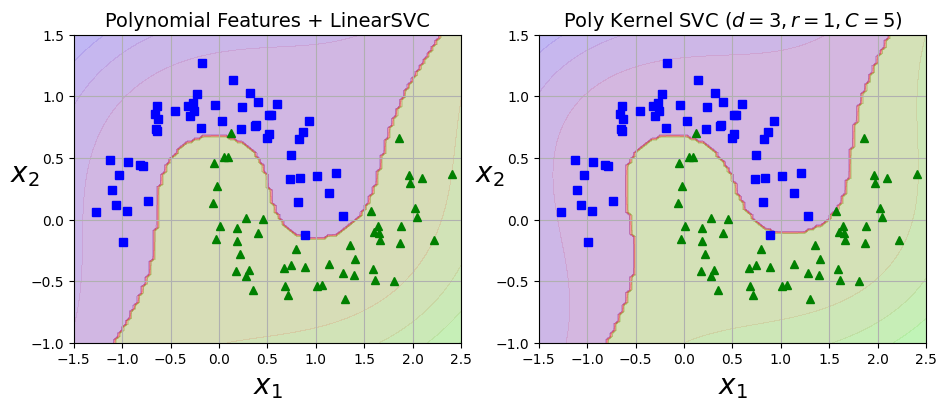

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_predictions(clf, axes):
    # 1. Create a meshgrid 
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    
    # 2. Get predictions
    y_pred = clf.predict(X_new).reshape(x0.shape)
    y_decision = clf.decision_function(X_new).reshape(x0.shape)
    
    # 3. Plot contours 
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs") # Blue squares
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^") # Green triangles
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

# --- Plotting the two models side by side ---
plt.figure(figsize=(11, 4))

# Plot 1: Polynomial Features + LinearSVC
plt.subplot(121)
plot_predictions(Polynomia_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(x, y, [-1.5, 2.5, -1, 1.5])
plt.title(r"Polynomial Features + LinearSVC", fontsize=14)

# Plot 2: Poly Kernel SVC
plt.subplot(122)
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(x, y, [-1.5, 2.5, -1, 1.5])
plt.title(r"Poly Kernel SVC ($d=3, r=1, C=5$)", fontsize=14)

plt.show()